### Complete Pipeline

In [18]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

from src.anomaly_detection import (
    detect_profile_shape_anomaly,
    detect_trend_anomaly,
    detect_event_response_anomaly,
)

from src.baselines import (
    FEATURE_COLS,
    stat_analysis,
    feat_engineering,
    split,
    isolation_forest,
    local_outlier_factor,
    prepare_lgb_dataset,
    evaluation,
    lgb_grid_search,
    show_cv_results,
)

### 0. Load data

In [19]:
df = pd.read_parquet("../data/processed/dataset_finale_2023-09-01_2025-09-30.parquet")

### 1. Heuristic anomaly detection (Baseline 0)

In [20]:
r1 = detect_profile_shape_anomaly(df)
r2 = detect_trend_anomaly(df)
r3 = detect_event_response_anomaly(df)

print("Anomaly 1 — shape  :", r1.shape, "| flagged:", r1["is_anomaly"].sum())
print("Anomaly 2 — trend  :", r2.shape, "| flagged:", r2["is_anomaly"].sum())
print("Anomaly 3 — events :", r3.shape, "| flagged:", r3["is_anomaly"].sum())

/home/giorgiab/projects/TrafficAnomalyDetection/src/anomaly_detection.py:35: RuntimeWarning: invalid value encountered in scalar divide
  peak_share = row[peak_hours].sum() / row.sum()
/home/giorgiab/projects/TrafficAnomalyDetection/src/anomaly_detection.py:35: RuntimeWarning: invalid value encountered in scalar divide
  peak_share = row[peak_hours].sum() / row.sum()
/home/giorgiab/projects/TrafficAnomalyDetection/src/anomaly_detection.py:35: RuntimeWarning: invalid value encountered in scalar divide
  peak_share = row[peak_hours].sum() / row.sum()
/home/giorgiab/projects/TrafficAnomalyDetection/src/anomaly_detection.py:35: RuntimeWarning: invalid value encountered in scalar divide
  peak_share = row[peak_hours].sum() / row.sum()
/home/giorgiab/projects/TrafficAnomalyDetection/src/anomaly_detection.py:35: RuntimeWarning: invalid value encountered in scalar divide
  peak_share = row[peak_hours].sum() / row.sum()
/home/giorgiab/projects/TrafficAnomalyDetection/src/anomaly_detection.py:35

Anomaly 1 — shape  : (475, 8) | flagged: 5
Anomaly 2 — trend  : (513, 9) | flagged: 175
Anomaly 3 — events : (152, 10) | flagged: 57


### 2. Statistical analysis — weather vs traffic

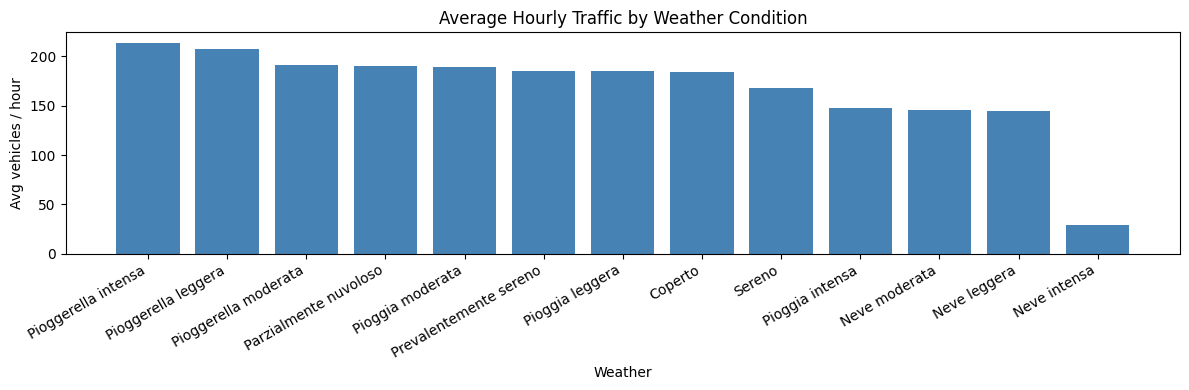

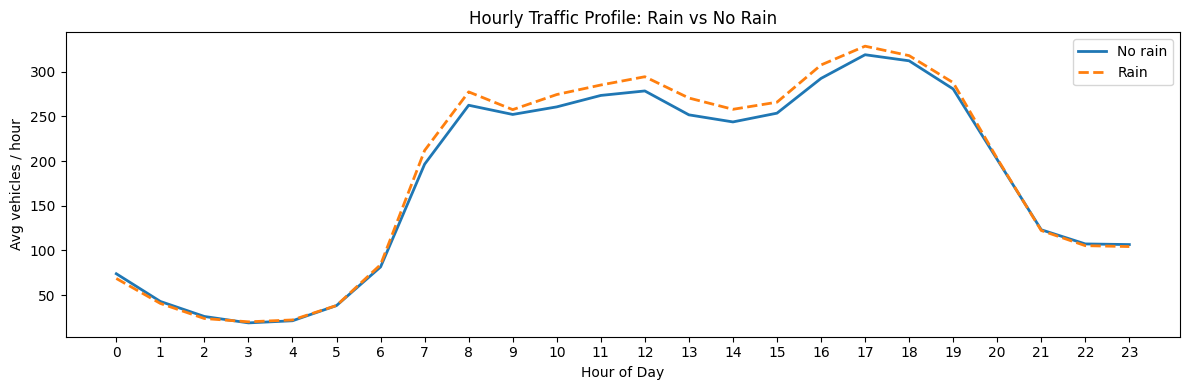

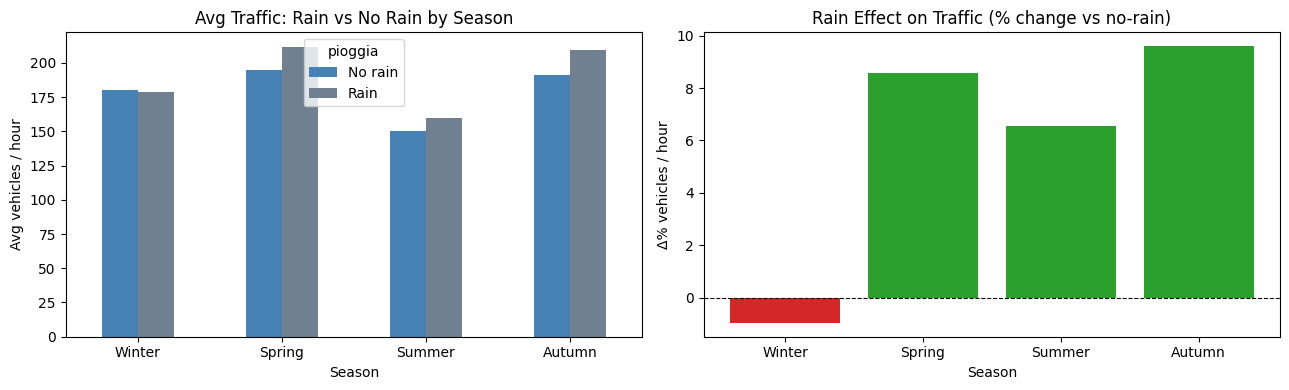

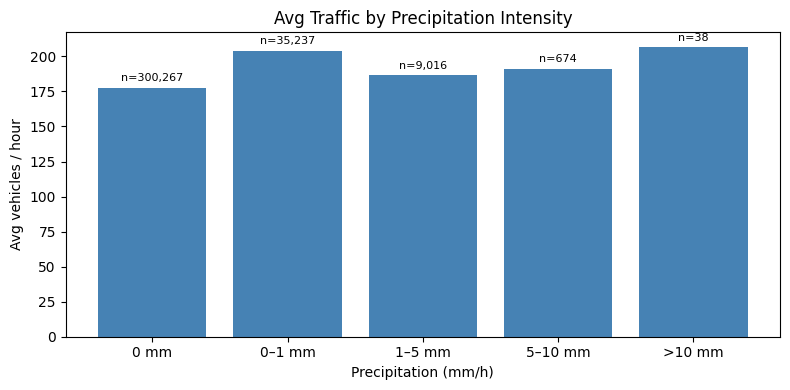

Pearson correlation with conteggio_veicoli:
precipitation     0.007275
wind_speed_10m    0.012142
pioggia           0.019331
temperature_2m    0.069523


In [21]:
weather_corr, precip_effect, df = stat_analysis(df)
# stat_analysis adds the precip_bin column to df and returns the updated dataframe

### 3. Feature engineering and temporal split

In [22]:
df_feat = feat_engineering(df)
# adds: hour, dow, lag_1h, lag_24h, lag_168h, rolling_mean_3h, rolling_mean_24h
# + encodes categorical columns

train, test = split(df_feat)
# train: data < 2025-01-01  |  test: data >= 2025-01-01

print(f"Train: {train.shape}  |  Test: {test.shape}")

Train: (221599, 42)  |  Test: (123633, 42)


### 4. Baseline 2a — Isolation Forest

In [23]:
result_if = isolation_forest(train, test)
# added columns: anomaly_score, anomaly_isolation  (-1 = anomaly, 1 = normal)

print("Flagged (IF):", (result_if["anomaly_isolation"] == -1).sum())
result_if[result_if["anomaly_isolation"] == -1][["data", "chiave", "conteggio_veicoli", "anomaly_score"]].head()

Flagged (IF): 799


,data,chiave,conteggio_veicoli,anomaly_score
162856,2025-09-10,525,687,-0.696981
162860,2025-09-10,525,675,-0.700629
162861,2025-09-10,525,581,-0.700104
163159,2025-09-22,525,820,-0.689569
338893,2025-01-08,896,1274,-0.688175


### 5. Baseline 2b — Local Outlier Factor

In [24]:
result_lof = local_outlier_factor(df_feat)
# added columns: anomaly_lof  (-1 = anomaly, 1 = normal), lof_score

print("Flagged (LOF):", (result_lof["anomaly_lof"] == -1).sum())
result_lof[result_lof["anomaly_lof"] == -1][["data", "chiave", "conteggio_veicoli", "lof_score"]].head()

Flagged (LOF): 3421


,data,chiave,conteggio_veicoli,lof_score
420,2023-09-18,83,248,-1.720167
733,2023-10-01,83,93,-1.584214
1240,2023-10-22,83,97,-1.520377
1349,2023-10-27,83,36,-1.476404
1350,2023-10-27,83,69,-1.551393


### 6. Baseline 3 — LightGBM forecasting

In [25]:
gbm = prepare_lgb_dataset(df_feat)

_, test_feat = split(df_feat)
X_test = test_feat[FEATURE_COLS]
y_test = test_feat["conteggio_veicoli"]

mse, mae = evaluation(gbm, X_test, y_test)

Training until validation scores don't improve for 5 rounds
Did not meet early stopping. Best iteration is:
[20]	valid_0's l2: 8453.94	valid_0's l1: 65.655
Mean Squared Error: 8453.94
Mean Absolute Error: 65.66


### 7. LightGBM hyperparameter grid search

In [ ]:
# lgb_grid_search calls feat_engineering internally: pass the raw df
gs = lgb_grid_search(df)

cv_results = show_cv_results(gs)
cv_results